<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Загрузка-библиотек" data-toc-modified-id="Загрузка-библиотек-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка библиотек</a></span></li><li><span><a href="#Загрузка-файла" data-toc-modified-id="Загрузка-файла-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Загрузка файла</a></span></li><li><span><a href="#Предобработка-и-исследовательский-анализ-данных" data-toc-modified-id="Предобработка-и-исследовательский-анализ-данных-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Предобработка и исследовательский анализ данных</a></span></li><li><span><a href="#Векторизация-текстовых-данных-с-использованием-TF-IDF" data-toc-modified-id="Векторизация-текстовых-данных-с-использованием-TF-IDF-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Векторизация текстовых данных с использованием TF-IDF</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#LogisticRegression" data-toc-modified-id="LogisticRegression-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>LogisticRegression</a></span></li><li><span><a href="#RandomForestClassifier" data-toc-modified-id="RandomForestClassifier-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>RandomForestClassifier</a></span></li><li><span><a href="#CatBoostClassifier" data-toc-modified-id="CatBoostClassifier-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>CatBoostClassifier</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Обучение-лучшей-модели-и-предсказание-на-тестовой-выборке" data-toc-modified-id="Обучение-лучшей-модели-и-предсказание-на-тестовой-выборке-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение лучшей модели и предсказание на тестовой выборке</a></span><ul class="toc-item"><li><span><a href="#Матрица-ошибок" data-toc-modified-id="Матрица-ошибок-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Матрица ошибок</a></span></li><li><span><a href="#Кривая-тoчнocти-пoлнoты" data-toc-modified-id="Кривая-тoчнocти-пoлнoты-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Кривая тoчнocти-пoлнoты</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Выводы</a></span></li></ul></div>

# Классификация токсичных комментариев

## Подготовка

###  Загрузка библиотек

In [1]:
!pip install -q imbalanced-learn
!pip install -q catboost
!pip install -q lightgbm
!pip install -q scikit-plot

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikitplot as skplt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.metrics import roc_curve, RocCurveDisplay, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from tqdm import tqdm
from tqdm import notebook

import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer 
import re
import spacy
from nltk.corpus import stopwords as nltk_stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Загрузка файла

In [3]:
data = pd.read_csv('/datasets/toxic_comments.csv')

pth1 = '/datasets/toxic_comments.csv'
pth2 = 'https://code.s3.yandex.net/toxic_comments.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1)
elif os.path.exists(pth2):
    data = pd.read_csv(pth2)
else:
    print('Something is wrong')

In [4]:
data.head()

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


В датасете 3 колонки и и 159292 строк. Пропущенных значений нет.

* Unnamed: 0 - нумерация строк
* text - тексты комментариев пользователей
* toxic - целевой признак, классифицификация комментариев на позитивные (0) и негативные (1)

### Предобработка и исследовательский анализ данных

Проверим наличие явных дубликатов в датасете

In [6]:
data.duplicated().sum()

0

Проверим баланс позитивных и негативных комментариев в датасете

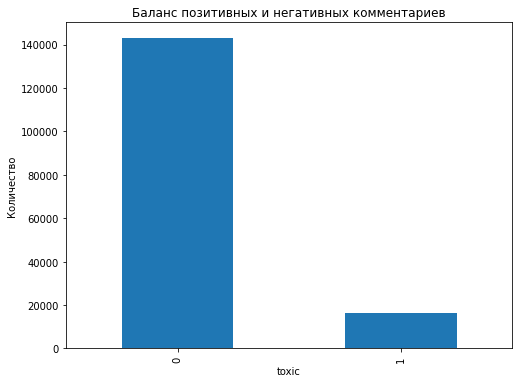

In [7]:
plt.figure(figsize=(8, 6))
data['toxic'].value_counts().plot(kind='bar')
plt.title('Баланс позитивных и негативных комментариев')
plt.xlabel('toxic')
plt.ylabel('Количество')
plt.show()

In [8]:
data.groupby('toxic').size().reset_index(name='count').sort_values(by='toxic')

,toxic,count
0,0,143106
1,1,16186


Позитивных комментариев значительно больше, чем негативных:

* позитивных (0) - 89,8%
* негативных (1) - 10,2%

Данные несбалансированны, нужно будет провести балансировку для улучшения производительности моделей. Будем применять даунсемплинг, так как в наших данных сильно преобладает один класс.

Сразу удалим столбец 'Unnamed: 0' с нумерацией строк, он будет лишним на этапе обучения

In [9]:
data = data.drop(['Unnamed: 0'], axis=1)

Еще раз проверим количество дублей

In [10]:
data.duplicated().sum()

0

**Перейдем к предобработке текстовых данных - столбец 'text'.**

* Очистим текст. Удалим специальные символы, цифры и пр., которые не являются буквами.

* Проведем лемматизацию, то есть приведем слова к их базовой форме (лемме). Это поможет уменьшить размерность и учесть различные формы слова.

* Удалим стоп-слова (english), которые обычно не несут смысловой нагрузки (напримпер, союзы, предлоги).

* Учтем части речи (существительные, глаголы, прилагательные и наречия). Лемматизация с учетом частей речи может улучшить качество предобработки, учитывая контекст использования слов.

Напишем для каждого шага отдельные функции и применим к столбцу 'text'

In [11]:
# Загрузим модели для предобработки
# nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
disabled_pipes = [ "parser",  "ner"]
nlp = spacy.load('en_core_web_sm', disable=disabled_pipes)

[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [12]:
# Очистка текста
def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Удаление всех символов, кроме букв
    text = text.lower()  # Приведение к нижнему регистру
    return text

In [13]:
# Лемматизация с учетом частей речи
def lemmatize_with_pos(text):
    doc = nlp(text)
    lemmatized_text = []
    for token in doc:
        if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']:  # Учитываем только существительные, глаголы, прилагательные и наречия
            lemmatized_text.append(token.lemma_)
    return ' '.join(lemmatized_text)

#Удаление стоп-слов
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return ' '.join(filtered_tokens)

In [14]:
# Объединение всех этапов предобработки
def preprocess_text(text):
    cleaned_text = clean_text(text)
    lemmatized_text = lemmatize_with_pos(cleaned_text)
    #final_text = remove_stopwords(lemmatized_text)
    return lemmatized_text

In [15]:
# Применение предобработки к столбцу 'text'
tqdm.pandas()
data['text'] = data['text'].progress_apply(preprocess_text)

100%|██████████| 159292/159292 [17:06<00:00, 155.18it/s]


In [16]:
data.head()

,text,toxic
0,explanation edit make username hardcore revert...,0
1,match background colour m seemingly stuck than...,0
2,man m really try edit war s just guy constantl...,0
3,more t make real suggestion improvement wonder...,0
4,hero chance remember page s,0


Проверим количество явных дублей после предобработки текстовых данных.

In [17]:
data.duplicated().sum()

4226

Удалим явные дубликаты

In [18]:
# Удалим явные дубли
data = data.drop_duplicates()

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 155066 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    155066 non-null  object
 1   toxic   155066 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ MB


Теперь у нас осталось 2 столбца и 155066 строк.

**Проведем балансировку классов с помощью даунсемплинга.**

Уменьшим число примеров в большем классе - 0 до числа примеров в меньшем классе - 1. Будем использовать библиотеку RandomUnderSampler.

In [20]:
X = data.drop('toxic', axis=1)
y = data['toxic']

In [21]:
# разделим модель на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(124052, 1) (31014, 1) (124052,) (31014,)


### Векторизация текстовых данных с использованием TF-IDF

Проведем векторизацию текстовых данных с использованием TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF - это статистическая мера, используемая для оценки важности слова в контексте документа, относительно коллекции документов или корпуса. TF-IDF часто используется в задачах обработки естественного языка (Natural Language Processing, NLP) для преобразования текстовых данных в числовые признаки, которые можно использовать для обучения моделей машинного обучения.

Класс TfidfVectorizer из библиотеки scikit-learn преобразует коллекцию текстовых документов в матрицу TF-IDF признаков. Он принимает текст в качестве входных данных и возвращает разреженную матрицу, где каждый элемент представляет собой TF-IDF вес слова в соответствующем документе.

In [22]:
# Создадим экземпляр TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Преобразуем текстовые данные в TF-IDF признаки
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['text'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['text'])

print("TF-IDF признаки для обучающего набора данных:", X_train_tfidf.shape)
print("TF-IDF признаки для тестового набора данных:", X_test_tfidf.shape)

TF-IDF признаки для обучающего набора данных: (124052, 97426)
TF-IDF признаки для тестового набора данных: (31014, 97426)


Данные подготовлены для обучения моделей.

### Вывод

На этапе предобработки и исследовательского анализа:

* Проверили данные на пропуски и явные дубликаты

* Удалили лишние столбцы ('Unnamed: 0' с нумерацией строк)

* Обработали текстовые данные в столбеце 'text':

    * Очистили текст от специальных символов, цифр и пр.
    * Привели слова к их базовой форме (лемме).
    * Учли части речи (существительные, глаголы, прилагательные и наречия).

* Разделили данные на тренировочную и тестовую выборки

* Провели векторизацию текстовых данных с использованием TF-IDF

## Обучение

Предстоит решить задачу **классификации**.

Для оценки качества моделей предлагается выбрать метрику **F1-мера** - это метрика, которая объединяет точность (precision) и полноту (recall) в одну числовую оценку.

Для решения задачи выберем и обучим на тренировочной выборке несколько моделей машинного обучения:

* LogisticRegression
* RandomForestClassifier
* CatBoostClassifier

### LogisticRegression

* Используем пайплайн из векторайзера (TfidfVectorizer) и модели (LogisticRegression) для того, чтобы избежать утечки данных при кросс-валидации.

* Исключим перебор гиперпараметра "solver" для модели LogisticRegression, так как он не сильно влияет на результат, а вместо этого сконцентрируемся на более важных параметрах, таких как "penalty", "C" и "fit_intercept".

In [24]:
pipeline = Pipeline([
    ('tfidf', tfidf_vectorizer),  # Используем ранее созданный экземпляр TfidfVectorizer
    ('model', LogisticRegression(random_state=42))  # Модель
])

# Параметры для поиска по сетке
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Диапазон n-грамм
    'model__penalty': ['l1', 'l2'],  # Тип регуляризации
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Параметр регуляризации
    'model__fit_intercept': [True, False]  # Интерсепт
}

# Поиск по сетке. В качестве оценки используем метрику f1
grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Обучаем модель только на обучающей выборке
grid_search.fit(X_train['text'], y_train)

# Получаем лучшие параметры и оценку
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Лучшие параметры: {best_params}')
print(f'Лучшая оценка F1-меры: {best_score}')

Лучшие параметры: {'model__C': 100, 'model__fit_intercept': True, 'model__penalty': 'l2', 'tfidf__ngram_range': (1, 2)}
Лучшая оценка F1-меры: 0.7654684879433498


### RandomForestClassifier

In [26]:
# Создаем пайплайн из векторайзера и модели RandomForestClassifier
pipeline_rf = Pipeline([
    ('tfidf', tfidf_vectorizer),
    ('model_rf', RandomForestClassifier(random_state=42, class_weight='balanced'))  # Модель
])

# Параметры для поиска по сетке
param_grid_rf = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Диапазон n-грамм
    'model_rf__n_estimators': [50, 100],  # Количество деревьев
    'model_rf__max_depth': [4, 10],  # Максимальная глубина деревьев
    'model_rf__min_samples_leaf': [1, 2] # Минимальное количество листьев
}

# Поиск по сетке. В качестве оценки используем метрику f1
grid_rf = GridSearchCV(pipeline_rf, param_grid=param_grid_rf, cv=3, scoring='f1', n_jobs=-1, verbose=2)

# Обучаем модель только на обучающей выборке
grid_rf.fit(X_train['text'], y_train)

# Получаем лучшие параметры и оценку
best_params_rf = grid_rf.best_params_
best_score_rf = grid_rf.best_score_

print(f'\nЛучшие параметры RandomForestClassifier: {best_params_rf}')
print(f'Лучшая оценка F1-меры: {best_score_rf}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=50, tfidf__ngram_range=(1, 1); total time=   4.0s
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=50, tfidf__ngram_range=(1, 1); total time=   3.9s
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=50, tfidf__ngram_range=(1, 1); total time=   3.9s
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=50, tfidf__ngram_range=(1, 2); total time=  13.2s
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=50, tfidf__ngram_range=(1, 2); total time=  14.4s
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=50, tfidf__ngram_range=(1, 2); total time=  13.9s
[CV] END model_rf__max_depth=4, model_rf__min_samples_leaf=1, model_rf__n_estimators=100, tfidf__ngram_range=(1, 1); total time= 

### CatBoostClassifier

In [27]:
# Создаем пайплайн для модели CatBoostClassifier
pipeline_cb = Pipeline(
    steps=[
        ('tfidf', tfidf_vectorizer),
        ('model_cb', CatBoostClassifier(random_state=42, verbose=True)) 
    ]
)

# Параметры для поиска по сетке
param_cb = {
    'model_cb__iterations': [100, 200],
    'model_cb__class_weights':([(1, 1), (1, 11)])
}

# Поиск по сетке. В качестве оценки используем метрику f1
grid_cb = GridSearchCV(pipeline_cb, param_grid=param_cb, cv=3, scoring='f1', n_jobs=-1)

# Обучаем модель только на обучающей выборке
grid_cb.fit(X_train['text'], y_train)

# Получаем лучшие параметры и оценку
best_params_cb = grid_cb.best_params_
score_cb = grid_cb.best_score_

print(f'\nЛучшие параметры CatBoostClassifier: {best_params_cb}')
print(f'Лучшая оценка F1-меры: {score_cb}')

Learning rate set to 0.5
0:	learn: 0.3374908	total: 1.78s	remaining: 2m 56s
1:	learn: 0.2567803	total: 3.02s	remaining: 2m 27s
2:	learn: 0.2309512	total: 4.26s	remaining: 2m 17s
3:	learn: 0.2199648	total: 5.49s	remaining: 2m 11s
4:	learn: 0.2122328	total: 6.68s	remaining: 2m 6s
5:	learn: 0.2050867	total: 7.88s	remaining: 2m 3s
6:	learn: 0.2002804	total: 9.07s	remaining: 2m
7:	learn: 0.1965955	total: 10.2s	remaining: 1m 57s
8:	learn: 0.1927790	total: 11.4s	remaining: 1m 55s
9:	learn: 0.1891593	total: 12.6s	remaining: 1m 53s
10:	learn: 0.1849387	total: 13.8s	remaining: 1m 51s
11:	learn: 0.1828158	total: 14.9s	remaining: 1m 49s
12:	learn: 0.1806573	total: 16.1s	remaining: 1m 47s
13:	learn: 0.1787212	total: 17.3s	remaining: 1m 46s
14:	learn: 0.1769256	total: 18.4s	remaining: 1m 44s
15:	learn: 0.1756519	total: 19.5s	remaining: 1m 42s
16:	learn: 0.1738115	total: 20.7s	remaining: 1m 40s
17:	learn: 0.1722388	total: 21.8s	remaining: 1m 39s
18:	learn: 0.1708820	total: 22.9s	remaining: 1m 37s
19:

Выведем итоговые результаты:

| Model                    | f1   |
|--------------------------|------|
| LogisticRegression       | 0.77 |
| RandomForestClassifier   | 0.35 |
| CatBoostClassifier       | 0.73 |

Лучший результат f1-меры у модели LogisticRegression метрика f1 0.77. Эту модель возьмем для обучения и предсказания на тестовой выборке.

### Вывод

Для решения задачи классификации были выбраны и обучены на тренировочной выборке несколько моделей машинного обучения:

* LogisticRegression
* RandomForestClassifier
* CatBoostClassifier

Для оценки качества моделей была выбрана метрика F1-мера.

В результате обучения лучший результат показала модель LogisticRegression c f1-мерой 0.77. Эту модель возьмем для обучения и предсказания на тестовой выборке.

## Обучение лучшей модели и предсказание на тестовой выборке

Обучим лучшую модель LogisticRegression на тестовой выборке, получим предсказания. Рассчитаем метрики: 
* F1-меры
* Precision
* Recall

In [34]:
# Обучим модель с лучшими гиперпараметрами
best_lr_model = grid_search.best_estimator_

# Предскажем на тестовой выборке
y_pred_lr = best_lr_model.predict(X_test['text'])

# Расчет F1-меры, Precision и Recall
f1_best_lr_model = f1_score(y_test, y_pred_lr)
precision_best_lr_model = precision_score(y_test, y_pred_lr)
recall_best_lr_model = recall_score(y_test, y_pred_lr, average='binary')

print(f'F1 на тестовой выборке для Logistic Regression: {f1_best_lr_model}')
print(f'Precision на тестовой выборке для Logistic Regression: {precision_best_lr_model}')
print(f'Recall на тестовой выборке для Logistic Regression: {recall_best_lr_model}')

F1 на тестовой выборке для Logistic Regression: 0.7844451894066377
Precision на тестовой выборке для Logistic Regression: 0.8577712609970675
Recall на тестовой выборке для Logistic Regression: 0.7226683137739345


Получили очень хороший результат на тестовыой выборке:
* F1-мера 0.78
* Precision 0.85
* Recall 0.72

### Матрица ошибок

Выведем полноту и точность на график «Матрица ошибок». 

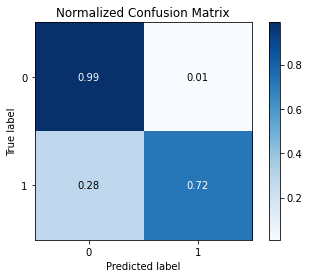

In [38]:
import scikitplot as skplt
skplt.metrics.plot_confusion_matrix(y_test, y_pred_lr, normalize=True)
plt.show()

Согласно матрице ошибок мы видим, что показатель True Positives (TP) довольно высок, это означает, что наша модель в 99% случаев верно предсказывает позитивные комментарии, модель ошибается лишь в 1% случаев.

Что касается оценки негативных комментариев True Negatives (TN), то тут модель тоже неплохо справляется. В 72% случаев распознает токсичные комментарии, ошибается в 28%.

### Кривая тoчнocти-пoлнoты

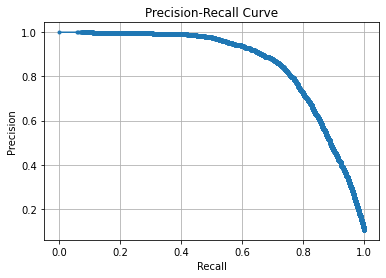

In [37]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Получение вероятности принадлежности к классу 1 (негативных комментариев)
probs = best_lr_model.predict_proba(X_test['text'])[:, 1]

# Вычисление precision и recall
precision, recall, _ = precision_recall_curve(y_test, probs)

# Построение кривой precision-recall
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

Линия начинает спускаться при увеличении Recall, что может указывать на уменьшение точности модели при повышении полноты. Когда линия достигает точки (1, 0), это означает, что модель предсказывает все объекты как положительные, что приводит к максимальной полноте (Recall = 1), но минимальной точности (Precision = 0).

## Выводы

1. На этапе предобработки и исследовательского анализа:

* Проверили данные на пропуски и явные дубликаты

* Удалили лишние столбцы ('Unnamed: 0' с нумерацией строк)

* Обработали текстовые данные в столбеце 'text':

    * Очистили текст от специальных символов, цифр и пр.
    * Привели слова к их базовой форме (лемме).
    * Учли части речи (существительные, глаголы, прилагательные и наречия).

* Разделили данные на тренировочную и тестовую выборки

* Провели векторизацию текстовых данных с использованием TF-IDF

2. На этапе обучения моделей на тренировочной выборке выбрали несколько моделей машинного обучения (для решения задачи классификации):

* LogisticRegression
* RandomForestClassifier
* CatBoostClassifier

Для оценки качества моделей была выбрана метрика F1-мера.

В результате обучения лучший результат показала модель LogisticRegression c f1-мерой 0.77. Эту модель взяли для обучения и предсказания на тестовой выборке.

3. В результате обучения лучшей модели LogisticRegression и предсказания на тестовой выборке получили неплохой результат:

* F1-мера 0.78
* Precision 0.85
* Recall 0.72

Таким образом, справились с поставленной задачей (построили модель со значением метрики качества F1 не меньше 0.75).